## Building a Simple Transformer

In [ ]:
#!pip install numpy
#!pip install torch
!pip install tqdm

Let's build step-by-step a very simple decoder-only Transformer model. Below is the architecture we'll follow.

For reference: `scaled_dot_product_attn = softmax(QK^T / sqrt(d_K))V`

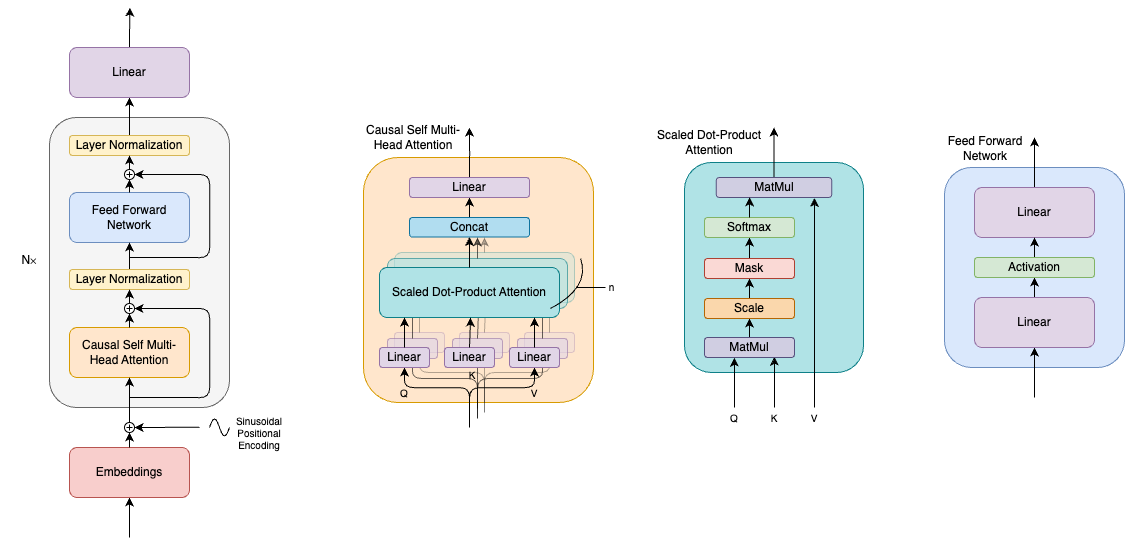

In [29]:
import torch
import torch.nn as nn
from typing import Optional, Tuple, List
import torch.nn.functional as F
from dataclasses import dataclass
from tqdm import tqdm
import math

In [ ]:
"""
B: batch size
L: sequence length
nH: number of heads
Hs: head size
H: hidden (channel / embedding / model) dimension [H = nH * Hs]
"""

@dataclass
class TransformerConfig:
    window_size: int = 256       # context window
    vocab_size: int = 1024       # vocabulary size
    n_layer: int = 6             # nb of transformer blocks
    n_head: int = 8              # nb of attention heads in MHA
    dim_model: int = 512            # hidden size of transformers
    head_size = 512//8
    vocab_size = None
    

    def __post_init__(self) -> None:
        assert(self.n_embd % self.n_head == 0)  # [H = nH * Hs]

In [ ]:
class FeedForwardNetwork(nn.Module):
    """ Feed Forward Network class: Implements a two-layer FFN"""
    def __init__(self, config: TransformerConfig) -> None:
        super().__init__()
        #TODO: Fill here (the FFN projects into a 4 times larger hidden space)
        self.fc1 = nn.Linear(config.dim_model, 4*config.dim_model)
        self.fc2 = nn.Linear(4*config.dim_model, config.dim_model)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape # B, T, dim_model
        x_out_1 = self.fc1(x) # B, T, 4*dim_model
        x_out_1 = F.gelu(x_out_1) # B, T, 4*dim_model
        x_out_2 = self.fc2(x_out_1) # B, T, dim_model
        return x_out_2

In [ ]:
class SelfAttentionHead(nn.Module):
    """ Attention class: Implements a Causal Self Attention Layer"""
    def __init__(self, config: TransformerConfig) -> None:
        super().__init__()
        self.config = config
        self.q_proj = nn.Linear(config.dim_model, config.dim_model)
        self.k_proj = nn.Linear(config.dim_model, config.dim_model)
        self.v_proj = nn.Linear(config.dim_model, config.dim_model)
        self.register_buffer("tril", torch.tril(torch.ones(config.window_size, config.window_size)), persistent=False)
        self.proj_o = nn.Linear(config.dim_model, config.dim_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, L, C = x.shape                                                               # (B, L, C)
        # build key, query and value tensors
        q = self.q_proj(x) #  (B, L, C)
        k = self.k_proj(x) #  (B, L, C)
        v = self.v_proj(x) #  (B, L, C)

        # reshape and re-arrange for multi head
        #TODO: Fill here (first add a head dimension, then swap dimensions to (B, nH, L, Hs))
        nH = self.config.n_head
        Hs = self.config.head_size
        q = q.reshape(B, L, nH, Hs)
        q = q.transpose(1, 2) # (B, nH, L, Hs)
        k = k.reshape(B, L, nH, Hs)
        k = k.transpose(1, 2) # (B, nH, L, Hs)
        v = v.reshape(B, L, nH, Hs)
        v = v.transpose(1, 2) # (B, nH, L, Hs)
        
        
        
        # perform scaled dot product
        #TODO: Fill here (matmul, scale, mask, softmax, matmul)
        scores = q @ k.transpose(2, 3) # B, nh, L, L
        scores = scores / math.sqrt(config.head_size)
        scores = scores.masked_fill(self.tril[:L, :L]==0, float('-inf'))
        scores = F.softmax(scores, dim=-1)
        ctx = scores @ v # B, nH, L, Hs
        
        # concat (re-assemble heads to (B, L, H))
        ctx = ctx.reshape(B, config.n_head, L, config.head_size)
        ctx = ctx.transpose(1, 2) #B, L, n_head, head_size
        ctx = ctx.reshape(B, L, config.head_size*config.n_head)
        
        # linear
        #TODO: Fill here
        x = self.proj_o(ctx)
        return x

In [36]:
head = SelfAttentionHead(TransformerConfig)

In [37]:
x = torch.ones((2, 6, 512))
head(x)

tensor([[[-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014]],

        [[-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014],
         [-0.0022, -0.1880,  0.3076,  ...,  0.5631,  0.0206,  0.2014]]],
       grad_fn=<ViewBackward0>)

In [9]:
class Decoder(nn.Module):
    """ Decoder class: Implements a decoder-only block layer"""
    def __init__(self, config) -> None:
        super().__init__()
        #TODO: Fill here

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        #TODO: Fill here
        return x

In [18]:
class Transformer(nn.Module):
    """ Transformer class: Implements a decoder-only transformer model"""
    def __init__(self, config: TransformerConfig) -> None:
        super().__init__()
        self.config = config
        #TODO: Fill here

    def sinusoidal_encodings(self, sequence_length: int) -> torch.Tensor:
        '''
        Build sinusoidal encodings for a L-size sequence
        '''
        encoding = torch.zeros((sequence_length, self.config.n_embd))               # (L, H)
        pos_ids = torch.arange(0, sequence_length, dtype=torch.long).view(-1,1)     # (1, H)
        indices = torch.arange(0, self.config.n_embd, 2).float().view(1,-1)         # (L, 1)

        encoding[:,0::2] = torch.sin(pos_ids / 10_000**(indices/self.config.n_embd))
        encoding[:,1::2] = torch.cos(pos_ids / 10_000**(indices/self.config.n_embd))

        return encoding

    def forward(self, input_ids: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor]:
        B, L = input_ids.shape
        assert L <= self.config.window_size, f"Input sequence is too large ({L} > {self.config.window_size})."

        # embeddings
        #TODO: Fill here

        # decoder blocks
        #TODO: Fill here
        
        # linear head
        logits = ... #TODO: Fill here

        # loss calculations
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))      # flatten on batch/seq logits before evaluation, targets is only tokens

        return logits, loss


    def generate(self, input_ids: torch.Tensor, new_tokens: int = 100) -> torch.Tensor:
        '''
        Simple greedy-decoding generate method
        '''
        for _ in range(new_tokens):
            with torch.no_grad():
                logits = self.forward(input_ids)[0]
                logits = logits[:, -1, :]

                probs = F.softmax(logits, dim=-1)
                next_token = torch.argmax(probs, dim=-1, keepdim=True)
                input_ids = torch.cat([input_ids, next_token], dim=-1)

        return input_ids

## Train and test your model

In [19]:
class DummyTokenizer:
    def __init__(self) -> None:
        self.char_to_token = {chr(i+32): i+1 for i in range(95)}
        self.token_to_char = {v: k for k, v in self.char_to_token.items()}

    def encode(self, text: List[str]) -> torch.Tensor:
        assert isinstance(text, List), "input texts must be a list"
        max_len = max(len(s) for s in text)
        tokens = [[self.char_to_token[char] for char in s.lower()] + [0]*(max_len-len(s)) for s in text]
        return torch.tensor(tokens, dtype=torch.long)

    def decode(self, tokens: torch.Tensor) -> List[str]:
        return [''.join([self.token_to_char[token.item()] for token in token_seq]) for token_seq in tokens]


In [ ]:
model = Transformer(TransformerConfig())
tokenizer = DummyTokenizer()
sentence = "attention is all you need - is a very nice paper!"

model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

for step in tqdm(range(150)):
    avg_loss = 0.0
    input_ids = tokenizer.encode([sentence])
    targets = input_ids.clone()[:,1:]
    input_ids = input_ids[:,:-1]

    optimizer.zero_grad()

    logits, loss = model(input_ids, targets)
    loss.backward()
    optimizer.step()

    avg_loss += loss.item()

    if step % 10 == 0:
        print(f"step: {step+1}, Loss: {avg_loss:.4f}")

In [ ]:
input_ids = tokenizer.encode(["att"])
output = model.generate(input_ids, new_tokens=46)
tokenizer.decode(output)[0]